In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv('zepto_hyperlocal_demand.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(by=['dark_store_id', 'item_category', 'timestamp'])

df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

grouped = df.groupby(['dark_store_id', 'item_category'])
df['sales_lag_1h'] = grouped['units_sold'].shift(1)
df['sales_lag_24h'] = grouped['units_sold'].shift(24)
df['rolling_mean_3h'] = grouped['sales_lag_1h'].transform(lambda x: x.rolling(window=3).mean())

df = df.dropna().reset_index(drop=True)

X = df.drop(columns=['timestamp', 'units_sold'])
y = df['units_sold']
X = pd.get_dummies(X, columns=['dark_store_id', 'item_category'], drop_first=True)

print(X.shape)

(4182, 11)


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

split_index = int(len(df) * 0.75)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 1.52
RMSE: 4.96


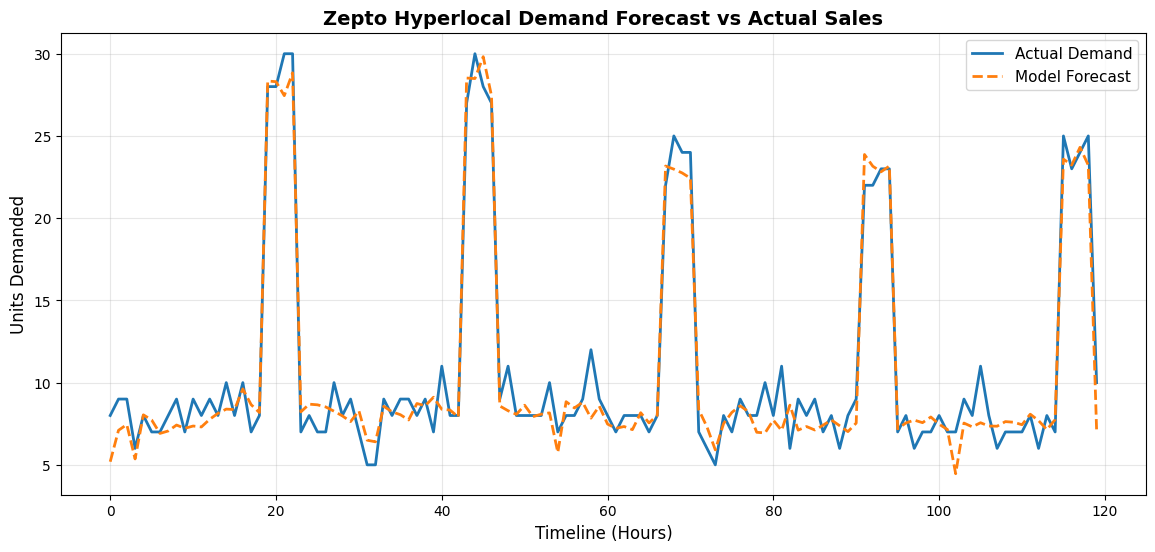

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.DataFrame({'Actual': y_test.values, 'Predicted': predictions})

plt.figure(figsize=(14, 6))
plt.plot(results.index[:120], results['Actual'].iloc[:120], label='Actual Demand', color='#1f77b4', linewidth=2)
plt.plot(results.index[:120], results['Predicted'].iloc[:120], label='Model Forecast', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('Zepto Hyperlocal Demand Forecast vs Actual Sales', fontsize=14, fontweight='bold')
plt.xlabel('Timeline (Hours)', fontsize=12)
plt.ylabel('Units Demanded', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()